### Importer les librairies

In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import xgboost as xgb
import lightgbm as lgb
from pathlib import Path

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")

BASE_DIR = Path().resolve().parent  # remonte d'un niveau depuis le notebook
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "model"

### **Importation des données**

In [3]:
data = pl.read_csv(DATA_DIR / "train.csv", null_values="NA")
data.head()
#data.schema voir si les types de différentes variables 

Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,…,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
i64,i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,str,str,i64,str,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,str,str,i64,str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,str,str,i64
1,60,"""RL""",65,8450,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""CollgCr""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,2003,2003,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",196,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""No""","""GLQ""",706,"""Unf""",0,…,854,0,1710,1,0,2,1,3,1,"""Gd""",8,"""Typ""",0,null,"""Attchd""",2003,"""RFn""",2,548,"""TA""","""TA""","""Y""",0,61,0,0,0,0,null,null,null,0,2,2008,"""WD""","""Normal""",208500
2,20,"""RL""",80,9600,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""FR2""","""Gtl""","""Veenker""","""Feedr""","""Norm""","""1Fam""","""1Story""",6,8,1976,1976,"""Gable""","""CompShg""","""MetalSd""","""MetalSd""","""None""",0,"""TA""","""TA""","""CBlock""","""Gd""","""TA""","""Gd""","""ALQ""",978,"""Unf""",0,…,0,0,1262,0,1,2,0,3,1,"""TA""",6,"""Typ""",1,"""TA""","""Attchd""",1976,"""RFn""",2,460,"""TA""","""TA""","""Y""",298,0,0,0,0,0,null,null,null,0,5,2007,"""WD""","""Normal""",181500
3,60,"""RL""",68,11250,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""CollgCr""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,2001,2002,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",162,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""Mn""","""GLQ""",486,"""Unf""",0,…,866,0,1786,1,0,2,1,3,1,"""Gd""",6,"""Typ""",1,"""TA""","""Attchd""",2001,"""RFn""",2,608,"""TA""","""TA""","""Y""",0,42,0,0,0,0,null,null,null,0,9,2008,"""WD""","""Normal""",223500
4,70,"""RL""",60,9550,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""Crawfor""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,1915,1970,"""Gable""","""CompShg""","""Wd Sdng""","""Wd Shng""","""None""",0,"""TA""","""TA""","""BrkTil""","""TA""","""Gd""","""No""","""ALQ""",216,"""Unf""",0,…,756,0,1717,1,0,1,0,3,1,"""Gd""",7,"""Typ""",1,"""Gd""","""Detchd""",1998,"""Unf""",3,642,"""TA""","""TA""","""Y""",0,35,272,0,0,0,null,null,null,0,2,2006,"""WD""","""Abnorml""",140000
5,60,"""RL""",84,14260,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""FR2""","""Gtl""","""NoRidge""","""Norm""","""Norm""","""1Fam""","""2Story""",8,5,2000,2000,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",350,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""Av""","""GLQ""",655,"""Unf""",0,…,1053,0,2198,1,0,2,1,4,1,"""Gd""",9,"""Typ""",1,"""TA""","""Attchd""",2000,"""RFn""",3,836,"""TA""","""TA""","""Y""",192,84,0,0,0,0,null,null,null,0,12,2008,"""WD""","""Normal""",250000
6,50,"""RL""",85,14115,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""Mitchel""","""Norm""","""Norm""","""1Fam""","""1.5Fin""",5,5,1993,1995,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""None""",0,"""TA""","""TA""","""Wood""","""Gd""","""TA""","""No""","""GLQ""",732,"""Unf""",0,…,566,0,1362,1,0,1,1,1,1,"""TA""",5,"""Typ""",0,null,"""Attchd""",1993,"""Unf

## **Préparation des données et Feature Engineering**

Dans cette étape, nous préparons les données avant la modélisation.
L’objectif est de :

corriger les valeurs manquantes en tenant compte du contexte métier
créer de nouvelles variables explicatives pertinentes (feature engineering)
transformer les types de variables pour les rendre exploitables par les modèles

### **Gestion des valeurs manquantes**

On remplace les NA qui signifient en réalité une absence.

In [248]:
data = data.with_columns([
    pl.col("GarageType").fill_null("NoGarage"),
    pl.col("GarageFinish").fill_null("NoGarage"),
    pl.col("GarageQual").fill_null("NoGarage"),
    pl.col("GarageCond").fill_null("NoGarage"),

    pl.col("BsmtQual").fill_null("NoBasement"),
    pl.col("BsmtCond").fill_null("NoBasement"),
    pl.col("BsmtExposure").fill_null("NoBasement"),
    pl.col("BsmtFinType1").fill_null("NoBasement"),
    pl.col("BsmtFinType2").fill_null("NoBasement"),

    pl.col("PoolQC").fill_null("NoPool"),
    pl.col("Fence").fill_null("NoFence"),
    pl.col("Alley").fill_null("NoAlley"),
    pl.col("MiscFeature").fill_null("None")
])
data

Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,…,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
i64,i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,str,str,i64,str,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,str,str,i64,str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,str,str,i64
1,60,"""RL""",65,8450,"""Pave""","""NoAlley""","""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""CollgCr""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,2003,2003,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",196,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""No""","""GLQ""",706,"""Unf""",0,…,854,0,1710,1,0,2,1,3,1,"""Gd""",8,"""Typ""",0,null,"""Attchd""",2003,"""RFn""",2,548,"""TA""","""TA""","""Y""",0,61,0,0,0,0,"""NoPool""","""NoFence""","""None""",0,2,2008,"""WD""","""Normal""",208500
2,20,"""RL""",80,9600,"""Pave""","""NoAlley""","""Reg""","""Lvl""","""AllPub""","""FR2""","""Gtl""","""Veenker""","""Feedr""","""Norm""","""1Fam""","""1Story""",6,8,1976,1976,"""Gable""","""CompShg""","""MetalSd""","""MetalSd""","""None""",0,"""TA""","""TA""","""CBlock""","""Gd""","""TA""","""Gd""","""ALQ""",978,"""Unf""",0,…,0,0,1262,0,1,2,0,3,1,"""TA""",6,"""Typ""",1,"""TA""","""Attchd""",1976,"""RFn""",2,460,"""TA""","""TA""","""Y""",298,0,0,0,0,0,"""NoPool""","""NoFence""","""None""",0,5,2007,"""WD""","""Normal""",181500
3,60,"""RL""",68,11250,"""Pave""","""NoAlley""","""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""CollgCr""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,2001,2002,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",162,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""Mn""","""GLQ""",486,"""Unf""",0,…,866,0,1786,1,0,2,1,3,1,"""Gd""",6,"""Typ""",1,"""TA""","""Attchd""",2001,"""RFn""",2,608,"""TA""","""TA""","""Y""",0,42,0,0,0,0,"""NoPool""","""NoFence""","""None""",0,9,2008,"""WD""","""Normal""",223500
4,70,"""RL""",60,9550,"""Pave""","""NoAlley""","""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""Crawfor""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,1915,1970,"""Gable""","""CompShg""","""Wd Sdng""","""Wd Shng""","""None""",0,"""TA""","""TA""","""BrkTil""","""TA""","""Gd""","""No""","""ALQ""",216,"""Unf""",0,…,756,0,1717,1,0,1,0,3,1,"""Gd""",7,"""Typ""",1,"""Gd""","""Detchd""",1998,"""Unf""",3,642,"""TA""","""TA""","""Y""",0,35,272,0,0,0,"""NoPool""","""NoFence""","""None""",0,2,2006,"""WD""","""Abnorml""",140000
5,60,"""RL""",84,14260,"""Pave""","""NoAlley""","""IR1""","""Lvl""","""AllPub""","""FR2""","""Gtl""","""NoRidge""","""Norm""","""Norm""","""1Fam""","""2Story""",8,5,2000,2000,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",350,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""Av""","""GLQ""",655,"""Unf""",0,…,1053,0,2198,1,0,2,1,4,1,"""Gd""",9,"""Typ""",1,"""TA""","""Attchd""",2000,"""RFn""",3,836,"""TA""","""TA""","""Y""",192,84,0,0,0,0,"""NoPool""","""NoFence""","""None""",0,12,2008,"""WD""","""Normal""",250000
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1456,60,"""RL""",62,7917,"""Pave""","""NoAlley""","""Reg""","""Lvl""","""AllPub""",""

### **Feature Engineering**

Création de nouvelles variables plus informatives

In [251]:

data = data.with_columns([
    (pl.col("YrSold") - pl.col("YearBuilt")).alias("AgeMaison"),
    (pl.col("YrSold") - pl.col("YearRemodAdd")).clip(lower_bound=0).alias("AgeRemod"),
    (pl.col("YrSold") - pl.col("GarageYrBlt").fill_null(pl.col("YearBuilt"))).clip(lower_bound=0).alias("AgeGarage"),
    (pl.col("TotalBsmtSF") + pl.col("1stFlrSF") + pl.col("2ndFlrSF")).alias("TotalSF"),
    (pl.col("OverallQual") * pl.col("GrLivArea")).alias("Qual_SF")
])

### **Exploration des données**

#### **Description des données**

Avant d’entamer l’analyse et la sélection des variables, nous avons examiné les types de chaque colonne du dataset. Certaines variables étaient mal typées (par exemple des codes numériques représentant des catégories ou des années traitées comme de simples entiers). Nous allons donc attribuer à chaque variable le type approprié : numériques continues, ordinales, catégorielles ou dates, afin d’assurer une analyse correcte et cohérente.

In [255]:
# Colonnes numériques mais catégorielles
categorical_numeric_cols = ["MSSubClass", "MoSold"]

data = data.with_columns([
    pl.col(col).cast(pl.Utf8).cast(pl.Categorical)
    for col in categorical_numeric_cols
])

# Colonnes catégorielles
categorical_string_cols = [
    "MSZoning","Street","LotShape","LandContour","Utilities","LotConfig","LandSlope",
    "Neighborhood","Condition1","Condition2","BldgType","HouseStyle","RoofStyle","RoofMatl",
    "Exterior1st","Exterior2nd","Foundation","Heating","CentralAir","Electrical","Functional",
    "GarageType","GarageFinish","PavedDrive","SaleType","SaleCondition",
    "PoolQC","MiscFeature","Alley","Fence"
]

data = data.with_columns([
    pl.col(col).cast(pl.Categorical)
    for col in categorical_string_cols
])

In [257]:
# Identifier les types de variables

# Toutes les colonnes castées correctement comme catégorielles
categorical_cols = [name for name, dtype in zip(data.columns, data.dtypes) if dtype == pl.Categorical]

# Toutes les colonnes numériques (Int64 / Float64)
numeric_cols = [name for name, dtype in zip(data.columns, data.dtypes) if dtype in [pl.Int64, pl.Float64]]

# Colonnes restantes → “autres” (dates / identifiants / éventuellement NA)
other_cols = [col for col in data.columns if col not in numeric_cols + categorical_cols]

print("Dimension du dataset :", data.shape)
print("Nombre de variables numériques :", len(numeric_cols))
print("Nombre de variables catégorielles :", len(categorical_cols))
print("Nombre d' autres variables (dates, identifiants..) :", len(other_cols))
print("Total :", len(numeric_cols) + len(categorical_cols) + len(other_cols))

Dimension du dataset : (1460, 86)
Nombre de variables numériques : 41
Nombre de variables catégorielles : 32
Nombre d' autres variables (dates, identifiants..) : 13
Total : 86


Le dataset contient 1460 observations et 81 variables décrivant les maisons vendues à Ames, incluant 34 numériques, 34 catégorielles et 13 dates ou identifiants. Les variables portent sur le terrain (LotArea, LotShape), la localisation (Neighborhood, MSZoning), la structure et le type de maison (MSSubClass, BldgType, HouseStyle), la qualité et l’état général (OverallQual, OverallCond), les surfaces et équipements (GrLivArea, TotalBsmtSF, FullBath, GarageCars, GarageArea), ainsi que les conditions de vente (SaleType, SaleCondition, YrSold). La variable cible est le prix de vente (SalePrice), que l’on cherche à expliquer ou prédire à partir des autres variables.

#### **Analyse des valeurs manquantes**

In [261]:
# fonction pour calculer les valeurs manquantes

def missing_percentage(df):
    """
    Calcule le pourcentage de valeurs manquantes pour chaque colonne
    et retourne un tableau trié par ordre décroissant.
    """
    
    missing_percent = (
        df.select([
            ((pl.col(c).is_null().sum() / df.height) * 100).alias(c)
            for c in df.columns
        ])
        .to_pandas()
        .T
        .rename(columns={0: "missing_percent"})
    )

    return missing_percent.sort_values("missing_percent", ascending=False)

In [263]:
# le pourcentage des valeurs manquantes

missing_percentage(data).head(15)

,missing_percent
FireplaceQu,47.260274
LotFrontage,17.739726
GarageYrBlt,5.547945
MasVnrType,0.547945
MasVnrArea,0.547945
Electrical,0.068493
Id,0.000000
Fireplaces,0.000000
GarageArea,0.000000
GarageCars,0.000000


Avant de proceder à la sélection des variables pour la modélisation, on enlève d'abord les variables peu informatives soit celles qui ont beaucoup des valeurs manquantes.

In [266]:
threshold = 0.5

data_clean = data.select([col for col in data.columns if data[col].null_count() / data.height <= threshold])

print(f"Nouvelle dimension du dataset : {data_clean.shape}")

Nouvelle dimension du dataset : (1460, 86)


In [268]:
# le pourcentage des valeurs manquantes

missing_percentage(data_clean)

,missing_percent
FireplaceQu,47.260274
LotFrontage,17.739726
GarageYrBlt,5.547945
MasVnrType,0.547945
MasVnrArea,0.547945
...,...
Foundation,0.000000
ExterCond,0.000000
ExterQual,0.000000
Exterior2nd,0.000000


#### **Sélection des variables importantes**

##### **Sélection des variables numériques**

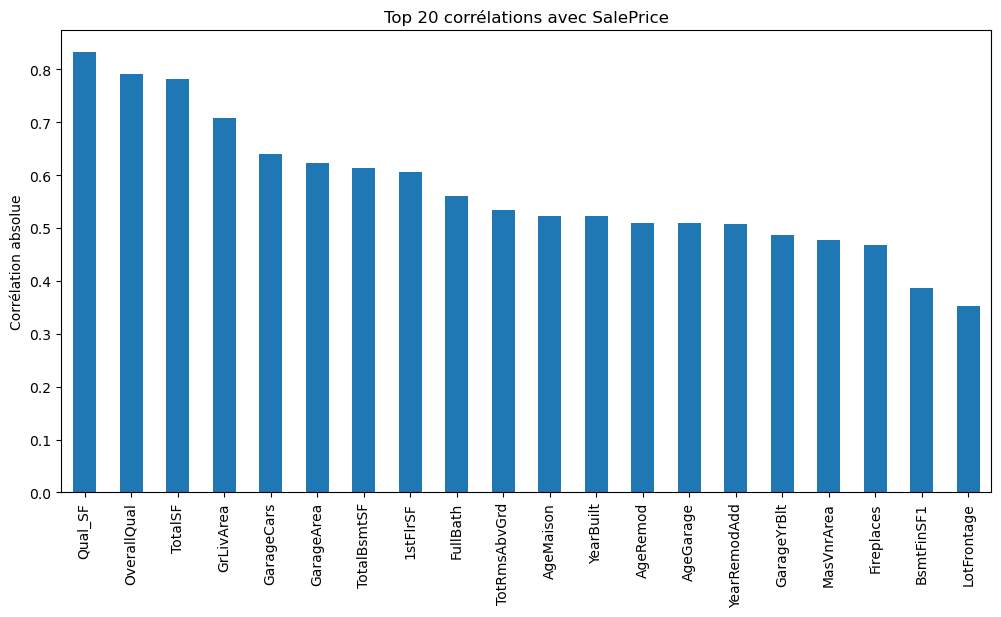

In [272]:
# Colonnes numériques (hors SalePrice)

numeric_cols = [col for col, dtype in zip(data_clean.columns, data_clean.dtypes)
                if dtype in [pl.Int64, pl.Float64] and col != "SalePrice"]

# Créer un DataFrame temporaire avec les colonnes numériques + SalePrice
df_num = data_clean.select(numeric_cols + ["SalePrice"])

# Calculer les corrélations en construisant un dictionnaire
correlations = {}
for col in numeric_cols:
    # Utilisation de select et expr corr
    corr_val = df_num.select(pl.corr(pl.col(col), pl.col("SalePrice"))).to_numpy()[0][0]
    correlations[col] = corr_val
    
# Transformer le dict en Series
corr_series = pd.Series(correlations)

# Trier par valeur absolue décroissante
corr_series_sorted = corr_series.abs().sort_values(ascending=False)

# Afficher un barplot des 20 variables les plus corrélées
plt.figure(figsize=(12,6))
corr_series_sorted.head(20).plot(kind="bar")
plt.title("Top 20 corrélations avec SalePrice")
plt.ylabel("Corrélation absolue")
plt.show()

In [274]:
top_10_cols = corr_series.abs().sort_values(ascending=False).head(10)
print("Top 10 variables numériques corrélées avec SalePrice :")
print(top_10_cols)

Top 10 variables numériques corrélées avec SalePrice :
Qual_SF         0.832057
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
dtype: float64


In [276]:
# les variables numériques gardées

numeric_selected = [
    "Qual_SF",
    "OverallQual",
    "TotalSF",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "FullBath",
    "AgeMaison",
    "YearBuilt",
    "AgeRemod",
    "AgeGarage"
]
print("Variables numériques retenues :")
print(numeric_selected)

Variables numériques retenues :
['Qual_SF', 'OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'FullBath', 'AgeMaison', 'YearBuilt', 'AgeRemod', 'AgeGarage']


À partir de l’analyse de la matrice de corrélation avec la variable cible SalePrice, nous retenons un ensemble de variables numériques présentant les corrélations les plus fortes. Nous analysons ensuite séparément les variables catégorielles afin de sélectionner celles qui apportent également une information pertinente.

##### **Sélection des variables catégorielles importantes**

Afin de sélectionner les variables catégorielles les plus pertinentes, nous utilisons le test ANOVA. Pour chaque variable, les observations contenant des valeurs manquantes pour cette variable ou pour la cible (SalePrice) sont exclues. Ce test permet de vérifier si le prix de vente (SalePrice) diffère significativement selon les catégories d’une variable. Une p-value inférieure à 0,05 indique que la variable a un effet significatif sur le prix de vente et peut donc être retenue pour l’analyse.

In [280]:
# les variables catégorielles 
categorical_cols_clean = [
    col for col, dtype in zip(data_clean.columns, data_clean.dtypes)
    if dtype == pl.Categorical
]

anova_results = {}

for col in categorical_cols_clean:

    df_temp = data_clean.select([col, "SalePrice"]).drop_nulls()

    groups = [
        group["SalePrice"].to_numpy()
        for group in df_temp.partition_by(col)
    ]

    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        anova_results[col] = p_val

anova_sorted = sorted(anova_results.items(), key=lambda x: x[1])

print("Variables catégorielles les plus significatives :")
for var, p in anova_sorted[:10]:
    print(f"{var}: p-value = {p:.5f}")

Variables catégorielles les plus significatives :
Neighborhood: p-value = 0.00000
GarageFinish: p-value = 0.00000
Foundation: p-value = 0.00000
GarageType: p-value = 0.00000
MSSubClass: p-value = 0.00000
SaleCondition: p-value = 0.00000
Exterior1st: p-value = 0.00000
Exterior2nd: p-value = 0.00000
SaleType: p-value = 0.00000
MSZoning: p-value = 0.00000


Même si toutes les variables catégorielles testées sont significatives selon le test ANOVA (p-value < 0,05), nous avons retenu six variables clés en appliquant un principe de parcimonie : Neighborhood (localisation), MSZoning (type de zone résidentielle), Foundation (qualité de construction), GarageFinish et GarageType (standing et type du garage), et SaleCondition (conditions de vente).
Ces variables couvrent les dimensions essentielles du marché immobilier tout en limitant la complexité du modèle.

In [283]:
cat_selected = [
    "Neighborhood",
    "GarageFinish",
    "GarageType",
    "MSZoning",
    "Foundation",
    "SaleCondition"
]

print("Variables catégorielles retenues :")
print(cat_selected)

Variables catégorielles retenues :
['Neighborhood', 'GarageFinish', 'GarageType', 'MSZoning', 'Foundation', 'SaleCondition']


Ces variables sont encodées via One-Hot Encoding dans le pipeline de prétraitement. L'option handle_unknown='ignore' permet de gérer les modalités inconnues lors de la prédiction.

#### **Statistiques descriptives**

On va générer les différentes fonctions réutilisables qui nous permettrons de faire des statistiques descriptives pour lss variables numériques et les variables catégorilles également.

In [287]:
## fonction pour décrire les variables catégorielles

def categorical_summary(df: pl.DataFrame, column: str) -> pl.DataFrame:
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found")

    df_non_null = df.filter(pl.col(column).is_not_null())
    total_n = df_non_null.height

    if total_n == 0:
        return pl.DataFrame(schema={
            "variable": pl.Utf8,
            "category": pl.Utf8,
            "n": pl.Int64,
            "percent": pl.Float64
        })

    return (
        df_non_null
        .group_by(column)
        .agg(pl.len().alias("n"))
        .with_columns(
            pl.lit(column).alias("variable"),
            (pl.col("n") / total_n * 100).round(1).alias("percent"),
            pl.col(column).cast(pl.Utf8).alias("category"),
        )
        .select(["variable", "category", "n", "percent"])
        .sort("n", descending=True)
    )

In [289]:
# fonction pour décrire les var numériques

def median_iqr_row(df: pl.DataFrame, col: str, label: str) -> pl.DataFrame:
    x = df[col].drop_nulls()

    if x.is_empty():
        return pl.DataFrame({"Characteristic": [label], "Value": [""]})

    med = x.median()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    return pl.DataFrame({
        "Characteristic": [label],
        "Value": [f"{med:.2f} ({q1:.2f} - {q3:.2f})"]
    })

In [291]:
# pour les années 

def min_max_row(df: pl.DataFrame, col: str, label: str) -> pl.DataFrame:
    x = df[col].drop_nulls()

    return pl.DataFrame({
        "Characteristic": [label],
        "Value": [f"{x.min()} - {x.max()}"]
    })

In [293]:
# pour les variables catégorielles

def block(df: pl.DataFrame, col: str, title: str) -> pl.DataFrame:
    s = categorical_summary(df, col)

    header = pl.DataFrame({
        "Characteristic": [title],
        "Value": [""]
    })

    if s.height == 0:
        return header

    rows = s.select(
        (pl.lit("  ") + pl.col("category")).alias("Characteristic"),
        pl.format("{} ({})", pl.col("n"), pl.col("percent")).alias("Value"),
    )

    return pl.concat([header, rows], how="vertical")

In [295]:
def build_table(df: pl.DataFrame) -> pl.DataFrame:

    parts = []

    # Taille dataset
    parts.append(pl.DataFrame({
        "Characteristic": ["n (observations)"],
        "Value": [str(df.height)]
    }))

    # SalePrice
    parts.append(median_iqr_row(df, "SalePrice", "SalePrice (median, IQR)"))

    # Variables numériques
    num_vars = [
        'GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF',
        'FullBath','TotRmsAbvGrd','AgeMaison','AgeRemod','AgeGarage'
    ]

    for col in num_vars:
        parts.append(median_iqr_row(df, col, col))

    # Dates
    parts.append(min_max_row(df, "YearBuilt", "YearBuilt (min-max)"))
    parts.append(min_max_row(df, "YearRemodAdd", "YearRemodAdd (min-max)"))

    # Variables catégorielles
    cat_vars = [
        'OverallQual','Neighborhood','GarageFinish',
        'SaleCondition','MSSubClass'
    ]

    for col in cat_vars:
        parts.append(block(df, col, col))

    return pl.concat(parts, how="diagonal_relaxed")

In [297]:
table1 = build_table(data_clean)
table1

Characteristic,Value
str,str
"""n (observations)""","""1460"""
"""SalePrice (median, IQR)""","""163000.00 (130000.00 - 214000.…"
"""GrLivArea""","""1464.00 (1130.00 - 1776.00)"""
"""GarageCars""","""2.00 (1.00 - 2.00)"""
"""GarageArea""","""480.00 (336.00 - 576.00)"""
…,…
""" 85""","""20 (1.4)"""
""" 75""","""16 (1.1)"""
""" 45""","""12 (0.8)"""


In [299]:
html = table1.to_pandas().to_html(index=False, border=0)
styled = f"""
<html><head><style>
    body {{ font-family: Arial, sans-serif; padding: 20px; }}
    table {{ border-collapse: collapse; width: 100%; }}
    th {{ background-color: #4472C4; color: white; padding: 8px 12px; text-align: left; }}
    td {{ padding: 7px 12px; border-bottom: 1px solid #ddd; }}
    tr:nth-child(even) {{ background-color: #f2f2f2; }}
</style></head><body>
{html}
</body></html>
"""
with open(MODEL_DIR.parent / "table1.html", "w", encoding="utf-8") as f:
    f.write(styled)
print("Sauvegardé")

Sauvegardé


#### **Analyse de la variable cible**

Afin d’analyser la distribution de la variable cible SalePrice, nous utilisons un histogramme ainsi qu’un boxplot.
L’histogramme permet de visualiser la forme générale de la distribution, tandis que le boxplot met en évidence la médiane, la dispersion des données et les éventuelles valeurs aberrantes.

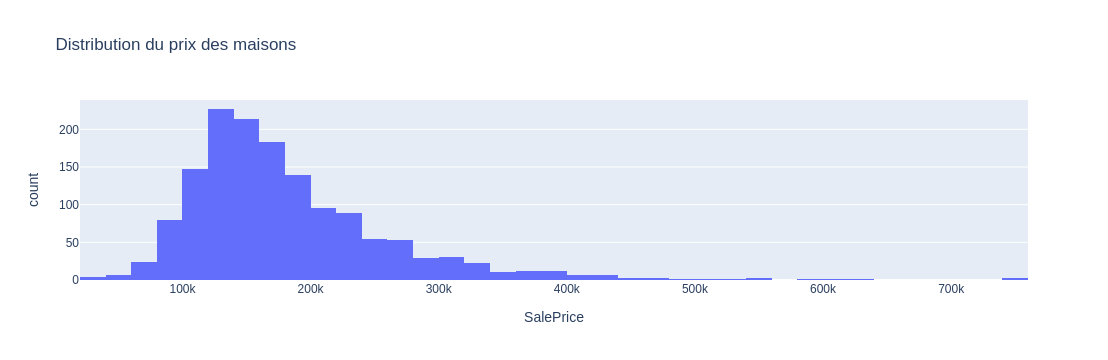

In [303]:
fig = px.histogram(
    data_clean.to_pandas(),
    x="SalePrice",
    nbins=50,
    title="Distribution du prix des maisons"
)

fig.show()

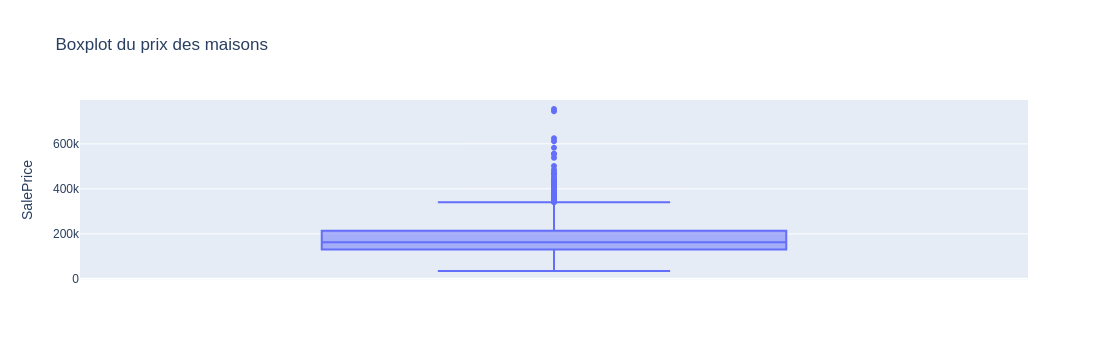

In [305]:
fig = px.box(
    data_clean.to_pandas(),
    y="SalePrice",
    title="Boxplot du prix des maisons"
)

fig.show()

L’analyse de la distribution de SalePrice montre une asymétrie positive ainsi que la présence de plusieurs valeurs extrêmes. Afin de réduire cette asymétrie et de stabiliser la variance, une transformation logarithmique de la variable cible sera utilisée dans les étapes de modélisation.

In [308]:
data_clean = data_clean.with_columns(
    np.log1p(pl.col("SalePrice")).alias("LogSalePrice")
)

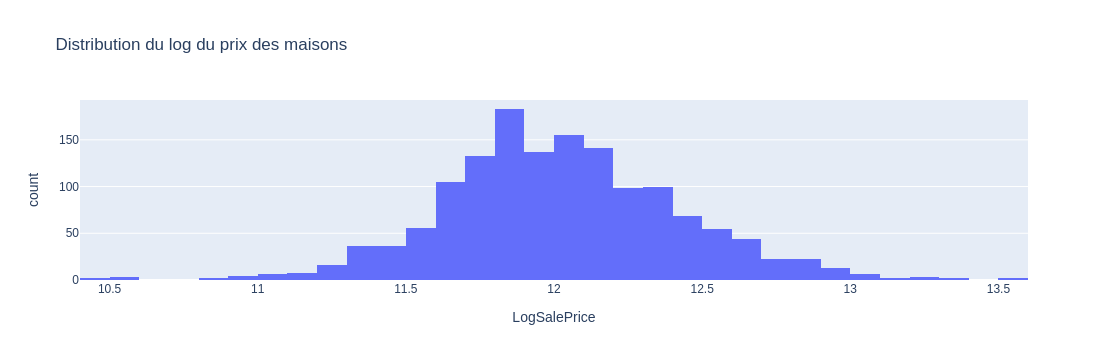

In [310]:
fig = px.histogram(
    data_clean.to_pandas(),
    x="LogSalePrice",
    nbins=50,
    title="Distribution du log du prix des maisons"
)

fig.show()

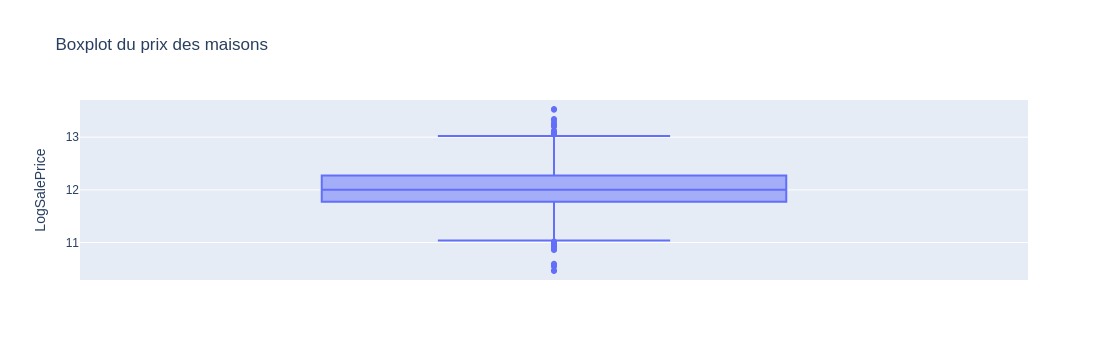

In [312]:
fig = px.box(
    data_clean.to_pandas(),
    y="LogSalePrice",
    title="Boxplot du prix des maisons"
)

fig.show()

Après transformation logarithmique de la variable cible SalePrice, la distribution devient plus symétrique et se rapproche d’une loi normale, ce qui est favorable à l’application des modèles de régression.Quelques valeurs extrêmes subsistent mais restent modérées. Étant donné leur faible influence et afin de ne pas perdre d’information, elles ont été conservées pour la modélisation.

#### **Dataset final**

In [316]:
# Colonnes finales

final_features = numeric_selected + cat_selected

cols_stats = final_features + ["SalePrice", "LogSalePrice", "Id"]

#  Dataset final

df_stats = data_clean.select(cols_stats).to_pandas()


print("Taille du dataset :", df_stats.shape)

Taille du dataset : (1460, 21)


In [318]:
# Infos sur les années (

first_year = data_clean["YearBuilt"].min()
last_year = data_clean["YearBuilt"].max()

print(f"\nLes maisons ont été construites entre {first_year} et {last_year}.")


Les maisons ont été construites entre 1872 et 2010.


In [320]:
print(df_stats.describe())

            Qual_SF  OverallQual       TotalSF    GrLivArea   GarageCars  \
count   1460.000000  1460.000000   1460.000000  1460.000000  1460.000000   
mean    9673.956164     6.099315   2567.048630  1515.463699     1.767123   
std     5186.744876     1.382997    821.714421   525.480383     0.747315   
min      334.000000     1.000000    334.000000   334.000000     0.000000   
25%     5790.000000     5.000000   2009.500000  1129.500000     1.000000   
50%     8820.000000     6.000000   2474.000000  1464.000000     2.000000   
75%    12180.000000     7.000000   3004.000000  1776.750000     2.000000   
max    56420.000000    10.000000  11752.000000  5642.000000     4.000000   

        GarageArea  TotalBsmtSF     FullBath    AgeMaison    YearBuilt  \
count  1460.000000  1460.000000  1460.000000  1460.000000  1460.000000   
mean    472.980137  1057.429452     1.565068    36.547945  1971.267808   
std     213.804841   438.705324     0.550916    30.250152    30.202904   
min       0.000000 

#### **Pipeline de prétraitement**

Afin de préparer les données pour la modélisation, un pipeline de prétraitement est mis en place. Celui-ci combine le traitement des variables numériques et catégorielles à l’aide d’un ColumnTransformer.

Cette approche permet d’appliquer automatiquement les transformations appropriées à chaque type de variable et garantit une préparation cohérente des données lors de l’entraînement et de la prédiction.


In [323]:
y = df_stats["LogSalePrice"]
X = df_stats.drop(columns=["SalePrice", "LogSalePrice", "Id"])

In [325]:
# vérifier les valeurs manquantes après l'imputation


missing_percent = data_clean.select([
    (pl.col(c).is_null().sum() / data_clean.height * 100).alias(c)
    for c in data_clean.columns
])

missing_percent

Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,…,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,AgeMaison,AgeRemod,AgeGarage,TotalSF,Qual_SF,LogSalePrice
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,17.739726,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.547945,0.547945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.260274,0.0,5.547945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **Modélisation**

Après la préparation des données, nous passons à la modélisation. L’objectif est de prédire le prix de vente des maisons à partir des variables sélectionnées. Nous commençons par une régression linéaire afin d’obtenir un premier modèle simple et évaluer ses performances.

#### **Séparation des données**

On commence par diviser nos données en jeu d’entraînement et jeu de test pour pouvoir évaluer le modèle sur des données qu’il n’a jamais vues

In [329]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
X_train.sample(1).to_csv(MODEL_DIR / "reference_input.csv", index=False)

In [331]:
# # Regroupement Neighborhood calculé uniquement sur le train

# train_full = X_train.copy()
# train_full["SalePrice"] = y_train.values

# neigh_stats = (
#     train_full.groupby("Neighborhood")["SalePrice"]
#     .mean()
#     .reset_index()
#     .rename(columns={"SalePrice": "mean_price"})
# )

# q1 = neigh_stats["mean_price"].quantile(0.33)
# q2 = neigh_stats["mean_price"].quantile(0.66)

# neigh_stats["NeighborhoodGroup"] = pd.cut(
#     neigh_stats["mean_price"],
#     bins=[-np.inf, q1, q2, np.inf],
#     labels=["Low", "Medium", "High"]
# )

# neigh_map = neigh_stats.set_index("Neighborhood")["NeighborhoodGroup"].to_dict()

# X_train["NeighborhoodGroup"] = X_train["Neighborhood"].map(neigh_map).fillna("Medium")
# X_test["NeighborhoodGroup"]  = X_test["Neighborhood"].map(neigh_map).fillna("Medium")


In [333]:
# Preprocessing

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_selected),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_selected)
])

In [335]:
models_and_spaces = {
    "Ridge": (
        Ridge(),
        {"model__alpha": Real(0.001, 10, prior="log-uniform")}
    ),
    "Lasso": (
        Lasso(max_iter=5000),
        {"model__alpha": Real(0.001, 1, prior="log-uniform")}
    ),
    "ElasticNet": (
        ElasticNet(max_iter=5000),
        {
            "model__alpha": Real(0.001, 1, prior="log-uniform"),
            "model__l1_ratio": Real(0.1, 0.9)
        }
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {
            "model__n_estimators": Integer(50, 300),
            "model__max_depth": Integer(4, 20),
            "model__min_samples_split": Integer(2, 10),
        }
    ),
    "XGBoost": (
        xgb.XGBRegressor(random_state=42, eval_metric="rmse"),
        {
            "model__n_estimators": Integer(300, 800),
            "model__max_depth": Integer(5, 10),
            "model__learning_rate": Real(0.01, 0.2, prior="log-uniform"),
            "model__subsample": Real(0.7, 1.0),
            "model__colsample_bytree": Real(0.7, 1.0),
        }
    ),
    "LightGBM": (
        lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
        {
            "model__n_estimators": Integer(150, 400),
            "model__num_leaves": Integer(20, 60),
            "model__learning_rate": Real(0.01, 0.15, prior="log-uniform"),
            "model__max_depth": Integer(4, 8),
            "model__min_child_samples": Integer(10, 50),
            "model__subsample": Real(0.7, 1.0),
            "model__colsample_bytree": Real(0.7, 1.0),
        }
    )
}

In [337]:
# Entraînement + tuning

best_models = {}
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for model_name, (model, param_space) in models_and_spaces.items():
    
    print(f"\n🔍 Optimisation de : {model_name}")
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    n_iter = 20 if model_name in ["LightGBM", "XGBoost"] else 10
    
    search = BayesSearchCV(
        pipe,
        param_space,
        n_iter=n_iter,
        cv=5, 
        scoring="r2",
        n_jobs=4,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print("✅ Meilleur score CV :", round(search.best_score_, 4))
    print("⚙️ Meilleurs paramètres :", search.best_params_)
    
    best_models[model_name] = search.best_estimator_
    
    joblib.dump(search.best_estimator_, MODEL_DIR / f"best_{model_name}.joblib")


🔍 Optimisation de : Ridge
✅ Meilleur score CV : 0.8353
⚙️ Meilleurs paramètres : OrderedDict([('model__alpha', 2.2364202820542705)])

🔍 Optimisation de : Lasso
✅ Meilleur score CV : 0.8257
⚙️ Meilleurs paramètres : OrderedDict([('model__alpha', 0.0010253943538922508)])

🔍 Optimisation de : ElasticNet
✅ Meilleur score CV : 0.829
⚙️ Meilleurs paramètres : OrderedDict([('model__alpha', 0.0010253943538922508), ('model__l1_ratio', 0.7542640157310013)])

🔍 Optimisation de : RandomForest
✅ Meilleur score CV : 0.8461
⚙️ Meilleurs paramètres : OrderedDict([('model__max_depth', 17), ('model__min_samples_split', 3), ('model__n_estimators', 200)])

🔍 Optimisation de : XGBoost
✅ Meilleur score CV : 0.8631
⚙️ Meilleurs paramètres : OrderedDict([('model__colsample_bytree', 0.7), ('model__learning_rate', 0.01), ('model__max_depth', 5), ('model__n_estimators', 800), ('model__subsample', 0.7)])

🔍 Optimisation de : LightGBM
✅ Meilleur score CV : 0.8591
⚙️ Meilleurs paramètres : OrderedDict([('model__co

In [338]:
# ================================
# Évaluation et résumé
# ================================
best_summary = []

for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # Métriques en log-prix
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    
    # Métriques en prix réels (dollars)
    y_pred_real = np.expm1(y_pred)
    y_test_real = np.expm1(y_test)
    rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae_real  = mean_absolute_error(y_test_real, y_pred_real)
    
    best_summary.append({
        "Modèle"    : model_name,
        "R²"        : round(r2, 4),
        "RMSE (log)": round(rmse, 4),
        "MAE (log)" : round(mae, 4),
        "RMSE ($)"  : round(rmse_real, 0),
        "MAE ($)"   : round(mae_real, 0)
    })

summary_df = pd.DataFrame(best_summary).sort_values(by="R²", ascending=False).reset_index(drop=True)
print("\n📊 Résumé des performances des modèles :")
print(summary_df)


📊 Résumé des performances des modèles :
         Modèle      R²  RMSE (log)  MAE (log)  RMSE ($)  MAE ($)
0         Ridge  0.8853      0.1463     0.1049   32643.0  19061.0
1       XGBoost  0.8826      0.1480     0.0985   26992.0  16983.0
2    ElasticNet  0.8811      0.1490     0.1061   31938.0  19149.0
3      LightGBM  0.8808      0.1492     0.0988   28012.0  17027.0
4         Lasso  0.8763      0.1520     0.1070   31895.0  19261.0
5  RandomForest  0.8701      0.1557     0.1033   31204.0  18278.0


### **Analyse du modèle : importance des variables (XGBoost + permutation importance)**

Après avoir entraîné et comparé plusieurs modèles de régression, le modèle XGBoost a été retenu comme le plus performant, avec un RMSE de 26 992 $ et un MAE de  16  983 $ — les meilleures performances en termes d'erreur en prix réels, ce qui est la métrique la plus pertinente pour un problème de prédiction immobilière.

Afin d'interpréter les prédictions du modèle, une analyse de l'importance des variables a été réalisée via la méthode de permutation importance. Cette technique consiste à mesurer la dégradation des performances du modèle lorsque les valeurs d'une variable sont perturbées aléatoirement — plus la dégradation est importante, plus la variable est déterminante.

Cette approche est préférable à l'analyse des coefficients, qui n'est pas applicable directement à XGBoost, et permet d'identifier les variables réellement déterminantes dans la prédiction des prix immobiliers.

In [341]:
# Récupérer le modèle XGBoost
xgb_pipeline = best_models["XGBoost"]
xgb_model = xgb_pipeline.named_steps["model"]

# Importance native XGBoost
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n🔍 Top 10 variables détaillées :")
print(feature_importance_df.head(10))


🔍 Top 10 variables détaillées :
                       feature  importance
1             num__OverallQual    0.144305
0                 num__Qual_SF    0.129540
2                 num__TotalSF    0.070663
47    cat__GarageType_NoGarage    0.061238
4              num__GarageCars    0.043454
52            cat__MSZoning_RM    0.029169
29   cat__Neighborhood_OldTown    0.027281
38  cat__GarageFinish_NoGarage    0.026430
40       cat__GarageFinish_Unf    0.023072
42      cat__GarageType_Attchd    0.019667


In [343]:
# Regroupement des variables

def clean_feature_name(feature):
    feature = feature.replace("num__", "").replace("cat__", "")
    
    # regrouper OneHot (ex: Neighborhood_NAmes → Neighborhood)
    if "_" in feature:
        return feature.split("_")[0]
    
    return feature

feature_importance_df["feature_clean"] = feature_importance_df["feature"].apply(clean_feature_name)

grouped_importance = (
    feature_importance_df
    .groupby("feature_clean")["importance"]
    .sum()
    .reset_index()
    .sort_values(by="importance", ascending=False)
)


print("\n📊 Top 15 variables regroupées :")
print(grouped_importance.head(15))


📊 Top 15 variables regroupées :
    feature_clean  importance
11   Neighborhood    0.181167
12    OverallQual    0.144305
13           Qual    0.129540
8      GarageType    0.123626
16        TotalSF    0.070663
7    GarageFinish    0.062151
10       MSZoning    0.059239
14  SaleCondition    0.046696
6      GarageCars    0.043454
3      Foundation    0.030002
2        AgeRemod    0.018432
17      YearBuilt    0.018229
1       AgeMaison    0.017095
15    TotalBsmtSF    0.015833
5      GarageArea    0.012017


In [360]:
# ================================
# Permutation importance
# ================================
result = permutation_importance(
    xgb_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print("\n🔝 Top 15 variables (permutation importance) :")
print(perm_importance_df.head(15))

# ================================
# Sauvegarde CSV
# ================================
perm_importance_df.to_csv(MODEL_DIR / "permutation_importance.csv", index=False)

print("\n✅ permutation_importance.csv sauvegardé")


🔝 Top 15 variables (permutation importance) :
          feature  importance
0         Qual_SF    0.253580
2         TotalSF    0.107026
1     OverallQual    0.037978
10       AgeRemod    0.027193
12   Neighborhood    0.018926
15       MSZoning    0.014225
6     TotalBsmtSF    0.010318
4      GarageCars    0.009899
5      GarageArea    0.009763
8       AgeMaison    0.006593
17  SaleCondition    0.005159
3       GrLivArea    0.003765
9       YearBuilt    0.003312
11      AgeGarage    0.002625
14     GarageType    0.002188

✅ permutation_importance.csv sauvegardé


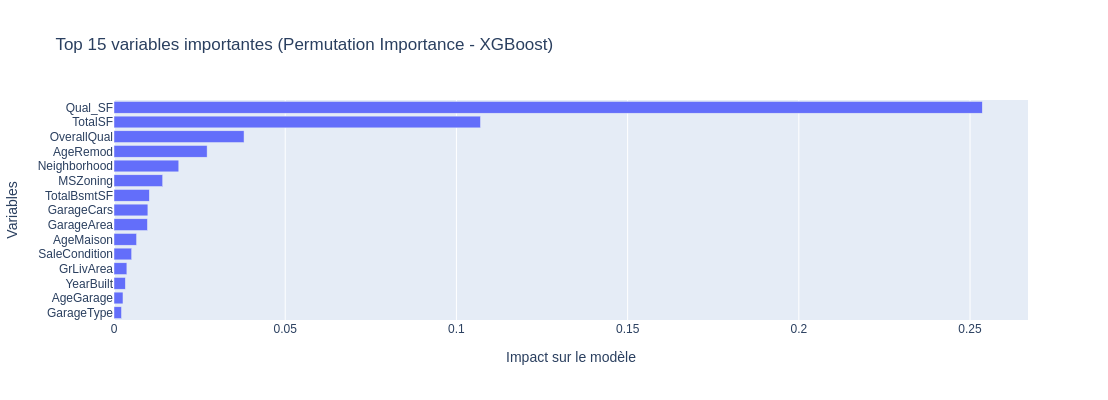

In [346]:
# Visualisation 
top_n = min(15, len(perm_importance_df))
top_features = perm_importance_df.head(top_n)
fig = px.bar(
    top_features,
    x="importance",
    y="feature",
    orientation="h",
    title=f"Top {top_n} variables importantes (Permutation Importance - XGBoost)",  # ← ici
    labels={
        "importance": "Impact sur le modèle",
        "feature": "Variables"
    }
)
fig.update_layout(
    height=400,
    yaxis=dict(autorange="reversed")
)
fig.show()

L’analyse des variables importantes permet de mieux comprendre comment le modèle prend ses décisions.
On observe que le prix des maisons dépend principalement de trois éléments : la qualité du bien, sa taille et les équipements disponibles.

La qualité apparaît comme le facteur le plus déterminant, avec des variables comme la qualité extérieure ou celle de la cuisine. Cela confirme qu’au-delà de la taille, le niveau de finition joue un rôle essentiel dans la valorisation d’un bien immobilier.

La surface habitable reste également un critère central, ce qui est logique puisque plus un logement est grand, plus sa valeur augmente.

Enfin, certains équipements comme le garage, la climatisation ou encore les cheminées contribuent aussi à faire varier les prix, traduisant l’importance du confort dans l’estimation immobilière.

Le modèle prend également en compte des éléments liés à la localisation, comme le quartier, ce qui montre qu’il est capable de capturer des effets plus globaux du marché.

Globalement, les résultats sont cohérents avec la réalité du marché immobilier, ce qui renforce la confiance dans les prédictions du modèle.

### **Analyse des erreurs et limites du modèle XGBoost**

Après avoir identifié les variables les plus importantes dans la prédiction des prix, il est essentiel d’analyser les erreurs du modèle afin de mieux comprendre ses limites et les situations dans lesquelles ses prédictions sont moins fiables.

In [350]:
# Définition explicite du modèle analysé
best_model_name = "XGBoost"
y_pred = best_models[best_model_name].predict(X_test)

# DataFrame d'analyse
results_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred
})

# Calcul des erreurs
results_df["error"] = results_df["y_true"] - results_df["y_pred"]
results_df["abs_error"] = results_df["error"].abs()

# Top erreurs
print("\n🔴 Top 10 des plus grosses erreurs :")
display(results_df.sort_values(by="abs_error", ascending=False).head(10))


🔴 Top 10 des plus grosses erreurs :


,y_true,y_pred,error,abs_error
197,10.596660,11.521597,-0.924937,0.924937
134,10.471978,11.283243,-0.811265,0.811265
181,10.933000,11.525872,-0.592872,0.592872
227,11.074436,11.577944,-0.503508,0.503508
43,12.442306,12.904181,-0.461875,0.461875
226,11.133143,11.530670,-0.397527,0.397527
81,11.112463,11.485052,-0.372589,0.372589
223,11.104972,11.460596,-0.355624,0.355624
287,11.401681,11.755710,-0.354029,0.354029
27,11.856522,11.532085,0.324437,0.324437


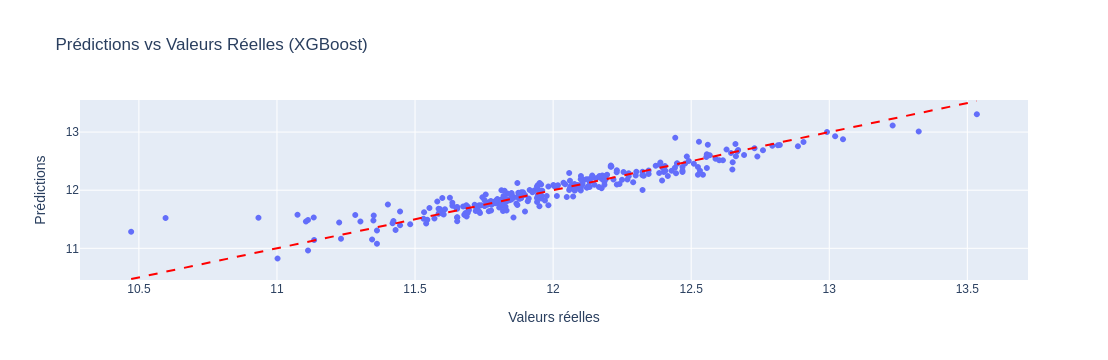

In [352]:
# Prédictions vs réalité

fig = px.scatter(
    results_df,
    x="y_true",
    y="y_pred",
    title=f"Prédictions vs Valeurs Réelles ({best_model_name})",
    labels={
        "y_true": "Valeurs réelles",
        "y_pred": "Prédictions"
    }
)

# Ligne parfaite
fig.add_shape(
    type="line",
    x0=results_df["y_true"].min(),
    y0=results_df["y_true"].min(),
    x1=results_df["y_true"].max(),
    y1=results_df["y_true"].max(),
    line=dict(color="red", dash="dash")
)

fig.show()

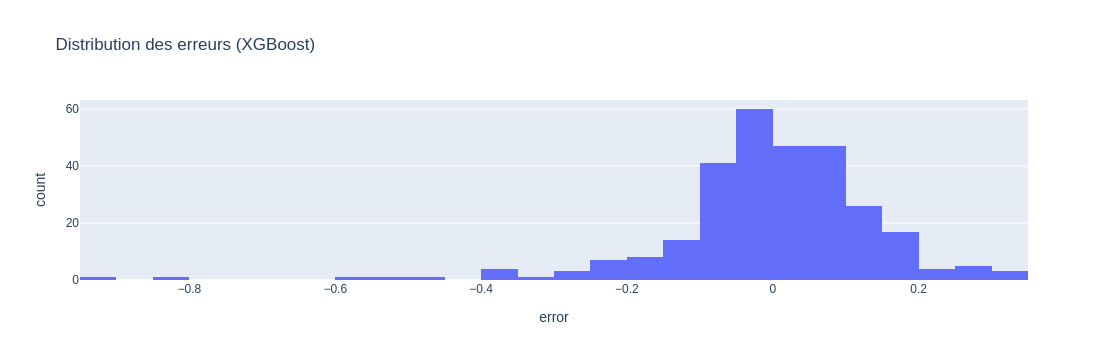

In [354]:
#  Distribution des erreurs

fig = px.histogram(
    results_df,
    x="error",
    nbins=50,
    title=f"Distribution des erreurs ({best_model_name})",
)

fig.show()

Les résultats montrent que le modèle est globalement très précis, avec des prédictions proches des valeurs réelles dans la majorité des cas.

On observe cependant quelques écarts pour les maisons les plus chères, où le modèle a tendance à légèrement surestimer les prix.

Malgré cela, les erreurs restent limitées et bien réparties autour de zéro, ce qui confirme que le modèle est fiable et bien équilibré.

### **Conclusion :**

Ce projet avait pour objectif de prédire le prix des maisons à partir de différentes caractéristiques du bien. Plusieurs modèles de machine learning ont été testés et optimisés via optimisation bayésienne. Le modèle XGBoost a été retenu comme le plus performant, avec un RMSE de 27 614 $ et un MAE de 17 900 $ — les meilleures performances en termes d'erreur en prix réels.
L'analyse de l'importance des variables a montré que le prix dépend principalement de la qualité du bien, de sa surface et des équipements disponibles. Ces résultats sont cohérents avec la réalité du marché immobilier.
L'étude des erreurs a confirmé la robustesse du modèle, tout en mettant en évidence certaines limites sur les biens les plus chers, qui restent plus difficiles à prédire.
Ce travail peut être prolongé par le développement d'une application interactive permettant de prédire le prix d'un bien en temps réel, facilitant ainsi son utilisation par des utilisateurs non techniques.


Corrige ces 4 points et le notebook sera propre et cohérent de bout en bout !